In [6]:
# ============================================
# 1. Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# ============================================
# 2. Load dataset
# ============================================
DATA_PATH = "balanced_network_data.csv"   # change this

df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)
print(df["Label"].value_counts().head(20))

Loaded shape: (6870587, 23)
Label
Benign                      4122352
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [8]:
# ============================================
# 3. Select features
# ============================================
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

missing = [c for c in network_features if c not in df.columns]
if missing:
    print("Missing features skipped:", missing)

network_features = [c for c in network_features if c in df.columns]
print("Using features:", len(network_features))

Using features: 22


In [9]:
# ============================================
# 4. Clean data
# ============================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Label"]).copy()

X = df[network_features].copy()
y = df["Label"].astype(str).copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("Cleaned X shape:", X.shape)
print(y.value_counts().head(20))

Cleaned X shape: (6838750, 22)
Label
Benign                      4091816
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193354
SSH-Bruteforce               187589
Infilteration                160639
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [10]:
# ============================================
# 5. Split benign vs attack
# ============================================
X_benign = X[y == "Benign"]
X_attack = X[y != "Benign"]
y_attack_labels = y[y != "Benign"]

print("Benign samples:", len(X_benign))
print("Attack samples:", len(X_attack))

Benign samples: 4091816
Attack samples: 2746934


In [11]:
# ============================================
# 6. Train/Validation split on benign only
# ============================================
# Train autoencoder using only benign traffic
X_train_raw, X_val_raw = train_test_split(
    X_benign,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Benign train shape:", X_train_raw.shape)
print("Benign val shape:", X_val_raw.shape)

Benign train shape: (3273452, 22)
Benign val shape: (818364, 22)


In [12]:
# ============================================
# 7. Scale features
# ============================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_attack_scaled = scaler.transform(X_attack)

print("Scaled shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Attack:", X_attack_scaled.shape)

Scaled shapes:
Train: (3273452, 22)
Val: (818364, 22)
Attack: (2746934, 22)


In [13]:
# ============================================
# 8. Build autoencoder
# ============================================
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)
encoded = Dense(4, activation="relu")(encoded)

# Decoder
decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(16, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │           374 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,098 (4.29 KB)

 Trainable params: 1,098 (4.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================
# 9. Train autoencoder
# ============================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.4478 - val_loss: 0.0480
Epoch 2/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.4232 - val_loss: 0.0766
Epoch 3/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.3695 - val_loss: 0.0477
Epoch 4/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.3044 - val_loss: 0.0721
Epoch 5/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.3018 - val_loss: 0.0493
Epoch 6/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.2686 - val_loss: 0.0624
Epoch 7/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.2607 - val_loss: 0.0334
Epoch 8/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.1916 - val_loss: 0.0314
Epoch 9/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.2439 - val_loss: 0.0279
Epoch 10/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.2042 - val_loss: 0.0308
Epoch 11/50
12787/12787 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.2254 - val_loss: 0.02

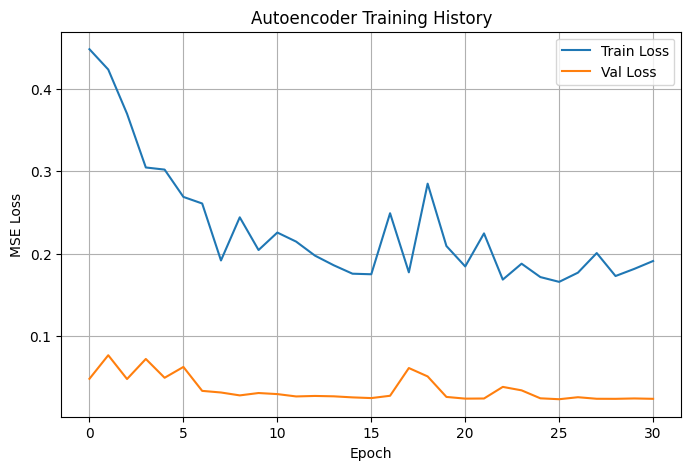

In [15]:
# ============================================
# 10. Plot training history
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ============================================
# 11. Reconstruction errors
# ============================================
# Benign validation reconstruction
X_val_pred = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.square(X_val - X_val_pred), axis=1)

# Attack reconstruction
X_attack_pred = autoencoder.predict(X_attack_scaled, verbose=0)
attack_mse = np.mean(np.square(X_attack_scaled - X_attack_pred), axis=1)

print("Validation error stats:")
print(pd.Series(val_mse).describe())

print("\nAttack error stats:")
print(pd.Series(attack_mse).describe())

Validation error stats:
count    818364.000000
mean          0.023250
std           5.713265
min           0.000040
25%           0.000111
50%           0.000342
75%           0.001232
max        4928.211202
dtype: float64

Attack error stats:
count    2.746934e+06
mean     6.239171e+01
std      2.334125e+03
min      4.906818e-05
25%      2.602033e-04
50%      2.171334e-03
75%      3.627908e-02
max      4.374377e+05
dtype: float64


In [17]:
# ============================================
# 12. Choose threshold from benign validation
# ============================================
# Try 95th percentile first
threshold = np.percentile(val_mse, 95)

print("Chosen threshold:", threshold)

Chosen threshold: 0.011228689930888863


In [18]:
# ============================================
# 13. Predict benign vs attack
# ============================================
# 0 = benign, 1 = attack
y_val_true = np.zeros(len(val_mse), dtype=int)
y_attack_true = np.ones(len(attack_mse), dtype=int)

y_val_pred = (val_mse > threshold).astype(int)
y_attack_pred = (attack_mse > threshold).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Confusion Matrix [[TN, FP],[FN, TP]]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))

Confusion Matrix [[TN, FP],[FN, TP]]:
[[ 777445   40919]
 [2027922  719012]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.28      0.95      0.43    818364
      Attack       0.95      0.26      0.41   2746934

    accuracy                           0.42   3565298
   macro avg       0.61      0.61      0.42   3565298
weighted avg       0.79      0.42      0.41   3565298



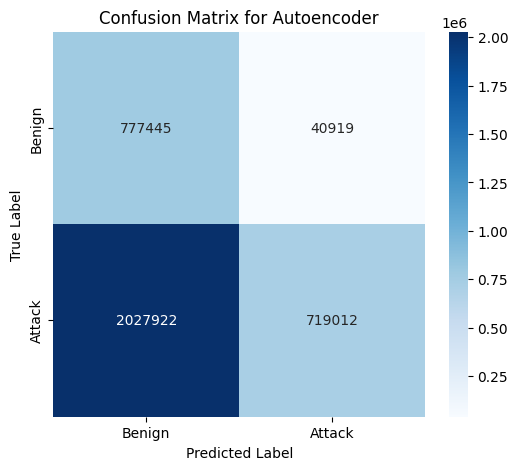

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [ 777445, 40919],
 [2027922, 719012]
])

labels = ["Benign", "Attack"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Autoencoder")

plt.show()

In [19]:
# ============================================
# 14. ROC-AUC using reconstruction error
# ============================================
y_scores = np.concatenate([val_mse, attack_mse])  # higher means more anomalous
auc = roc_auc_score(y_true, y_scores)
print("ROC-AUC:", auc)

ROC-AUC: 0.7442250598199494


In [20]:
# ============================================
# 15. Threshold tuning
# ============================================
for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(val_mse, p)

    y_val_pred = (val_mse > thr).astype(int)
    y_attack_pred = (attack_mse > thr).astype(int)

    y_true = np.concatenate([np.zeros(len(y_val_pred)), np.ones(len(y_attack_pred))])
    y_pred = np.concatenate([y_val_pred, y_attack_pred])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    benign_recall = tn / (tn + fp + 1e-12)
    attack_recall = tp / (tp + fn + 1e-12)
    attack_precision = tp / (tp + fp + 1e-12)

    print(f"\nThreshold percentile: {p}")
    print("Threshold:", thr)
    print(cm)
    print(f"Benign Recall: {benign_recall:.4f}")
    print(f"Attack Recall: {attack_recall:.4f}")
    print(f"Attack Precision: {attack_precision:.4f}")


Threshold percentile: 90
Threshold: 0.00530566788321178
[[ 736528   81836]
 [1834038  912896]]
Benign Recall: 0.9000
Attack Recall: 0.3323
Attack Precision: 0.9177

Threshold percentile: 92
Threshold: 0.006644475604393108
[[ 752894   65470]
 [1836904  910030]]
Benign Recall: 0.9200
Attack Recall: 0.3313
Attack Precision: 0.9329

Threshold percentile: 95
Threshold: 0.011228689930888863
[[ 777445   40919]
 [2027922  719012]]
Benign Recall: 0.9500
Attack Recall: 0.2618
Attack Precision: 0.9462

Threshold percentile: 97
Threshold: 0.02620122292646594
[[ 793813   24551]
 [2046638  700296]]
Benign Recall: 0.9700
Attack Recall: 0.2549
Attack Precision: 0.9661

Threshold percentile: 99
Threshold: 0.08602687696466303
[[ 810180    8184]
 [2216744  530190]]
Benign Recall: 0.9900
Attack Recall: 0.1930
Attack Precision: 0.9848


In [21]:
# ============================================
# 16. Per-attack detection rate
# ============================================
attack_labels = y_attack_labels.value_counts().index.tolist()

rows = []
for lab in attack_labels:
    X_lab = X[y == lab]
    X_lab_scaled = scaler.transform(X_lab)

    X_lab_pred = autoencoder.predict(X_lab_scaled, verbose=0)
    lab_mse = np.mean(np.square(X_lab_scaled - X_lab_pred), axis=1)

    y_lab_pred = (lab_mse > threshold).astype(int)
    detection_rate = y_lab_pred.mean()

    rows.append((lab, len(X_lab), detection_rate))

report_df = pd.DataFrame(rows, columns=["Attack Label", "Samples", "Detection Rate"])
report_df = report_df.sort_values("Detection Rate", ascending=False)

print(report_df)

                Attack Label  Samples  Detection Rate
10      DDOS attack-LOIC-UDP     1730        1.000000
4             FTP-BruteForce   193354        0.999995
7   DoS attacks-SlowHTTPTest   139890        0.999979
5             SSH-Bruteforce   187589        0.981220
9      DoS attacks-Slowloris    10990        0.513376
12          Brute Force -XSS      230        0.482609
11          Brute Force -Web      611        0.315876
0           DDOS attack-HOIC   686012        0.238879
6              Infilteration   160639        0.141055
13             SQL Injection       87        0.126437
3                        Bot   286191        0.016241
8      DoS attacks-GoldenEye    41508        0.013491
2           DoS attacks-Hulk   461912        0.003206
1     DDoS attacks-LOIC-HTTP   576191        0.001383
